In [71]:
# Theoretical and Real AVO analysis using raw seismic data from KOPRI
# Zachary Katz
# 27 November 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os
import pandas as pd
from scipy.signal import find_peaks
import scipy

############
line = '21YY'
geometry_path = f'./_data/KPDC_David_Seismic_2022/RAW/{line}-Geometry.csv' 
sgy_file = f'./_data/KPDC_David_Seismic_2022/RAW/{line}'
num_shots = 20 # Number of shots on this Line [X=56, Y=40, XX=28. YY=20]
############

sgy_path = sgy_file + '.sgy'

def segyload_obspy(sgy_path, fldr_number=1):
    # Load entire SEG-Y file
    st = _read_segy(sgy_path, unpack_trace_headers=True)

    # Sampling values
    dt = st[0].stats.delta          # seconds
    ns = st[0].stats.npts
    time = np.arange(ns) * dt       # seconds

    # Select traces based on Field Record Number (fldr)
    selected_traces = []
    coords = {'source_x': [], 'source_y': [], 'group_x': [], 'group_y': []}
    for tr in st:
        hdr = tr.stats.segy.trace_header
        if hdr.original_field_record_number == fldr_number:
            selected_traces.append(tr.data)
            coords['source_x'].append(hdr.source_coordinate_x)
            coords['source_y'].append(hdr.source_coordinate_y)
            coords['group_x'].append(hdr.group_coordinate_x)
            coords['group_y'].append(hdr.group_coordinate_y)

    if len(selected_traces) == 0:
        raise ValueError(f"No traces found for fldr={fldr_number}")

    data = np.stack(selected_traces)
    n_traces = data.shape[0]
    

    # Percentile clipping
    #lower_clip = np.percentile(data, 0.05)
    #upper_clip = np.percentile(data, 99.95)
    #data_clipped = np.clip(data, lower_clip, upper_clip)
    data_clipped = data

    # Transpose to (ns, n_traces) like segyio version
    data_clipped = data_clipped.T

    return data_clipped, time, n_traces, coords

# Make theoretical AVO curves
def Aki_Richards_ZoeppritzApprox(angles, p1, p2, s1, s2, rho1, rho2):
    thetas = np.deg2rad(angles)
    p = (p1 + p2) / 2
    delta_p = p2 - p1
    s = (s1 + s2) / 2
    delta_s = s2 - s1
    rho = (rho1 + rho2) / 2
    delta_rho = rho2 - rho1

    term1 = 0.5 * ( 1 + np.tan(thetas)*np.tan(thetas)) * delta_p / p
    term2 = (4 * (s*s) / (p * p) * np.sin(thetas) * np.sin(thetas) * delta_s / s)
    term3 = 0.5 * ( 1 -4 * (s*s) / (p * p) * np.sin(thetas) * np.sin(thetas))* delta_rho / rho

    return term1 - term2 + term3

def Shuey_ZoeppritzApprox(angles, p1, p2, s1, s2, rho1, rho2):
    
    thetas = np.deg2rad(angles)
    p = (p1 + p2) / 2
    delta_p = p2 - p1
    s = (s1 + s2) / 2
    delta_s = s2 - s1
    rho = (rho1 + rho2) / 2
    delta_rho = rho2 - rho1
    
    R0 = 0.5 * (delta_p / p + delta_rho / rho)
    k = (s / p) ** 2
    G = 0.5 * (delta_p / p) - 2.0 * k * (delta_rho / rho + 2.0 * delta_s / s)
    F = 0.5 * (delta_p / p)
    R = R0 + G * np.sin(thetas)**2 + F * (np.tan(thetas)**2 - np.sin(thetas)**2)
    return R, R0, G


# Ice properties for theoretical curves
alpha_Ice = 3810
beta_Ice = 1860
rho_Ice =  920

materials = {
    "Water": {
        "alpha": 1500,
        "beta": 0,
        "rho": 997,
    },
    "Basement": {
        "alpha": 5200,
        "beta": 2800,
        "rho": 2700,
    },
    "Stiff": {
        "alpha": 1800,
        "beta": 1000,
        "rho": 1900,
    },
    "Dilatant": {
        "alpha": 1700,
        "beta": 200,
        "rho": 1800,
    },
    "Lithified": {
        "alpha": 3750,
        "beta": 2450,
        "rho": 2450,
    },
}


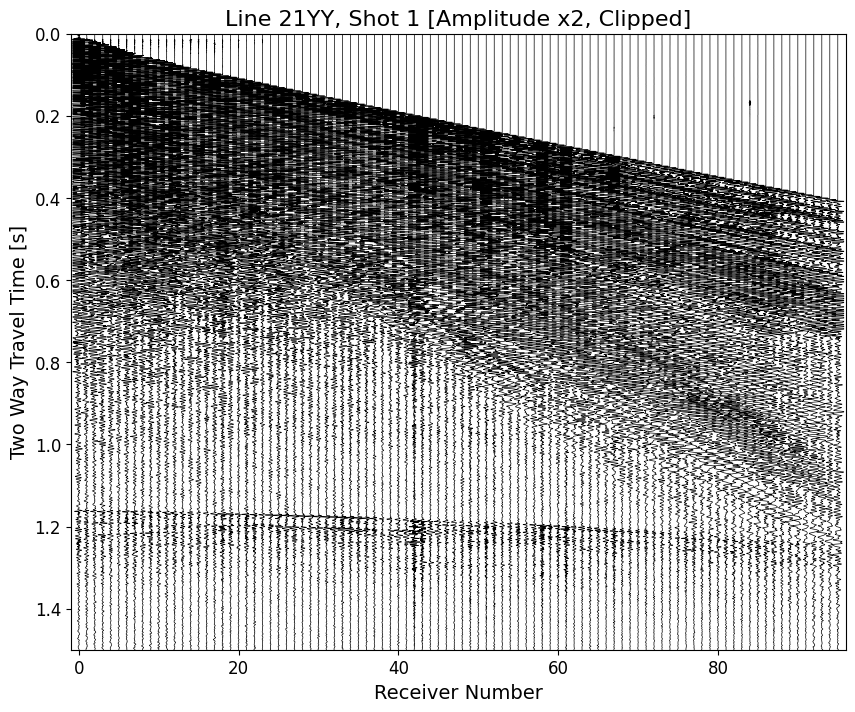

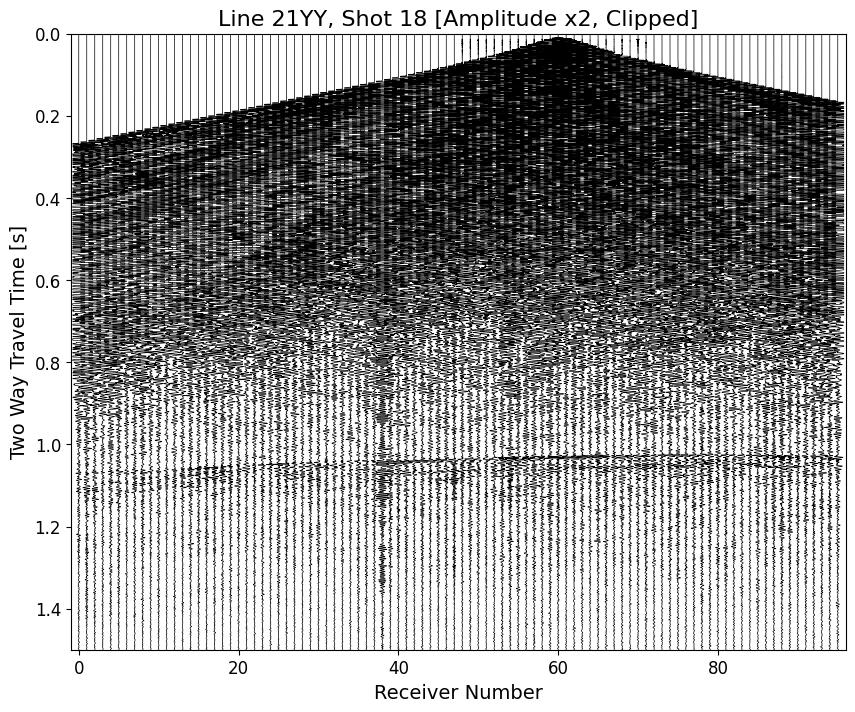

In [72]:
# Full shot as an example for PPT
for index, fldr_number in enumerate([1,18]):
    fig, ax = plt.subplots(figsize=(10, 8))
    data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)
    geometry = pd.read_csv(geometry_path)
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
    traces = data_clipped
    for trace_no, trace in enumerate(traces.T):
        trace = trace * 2
        trace = np.clip(trace, -0.75, 0.75)
        x = trace_no * np.ones_like(trace) + trace
        ax.plot(x, time, color='k', linewidth=0.5)

    ax.set_ylim(1.5,0)
    ax.set_xlim(-1, n_traces)
    #ax.set_ylim(1.5,1)
    ax.set_xlabel("Receiver Number",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.set_title(f"Line {line}, Shot {fldr_number} [Amplitude x2, Clipped]",fontsize=16)
    ax.tick_params(labelsize=12)

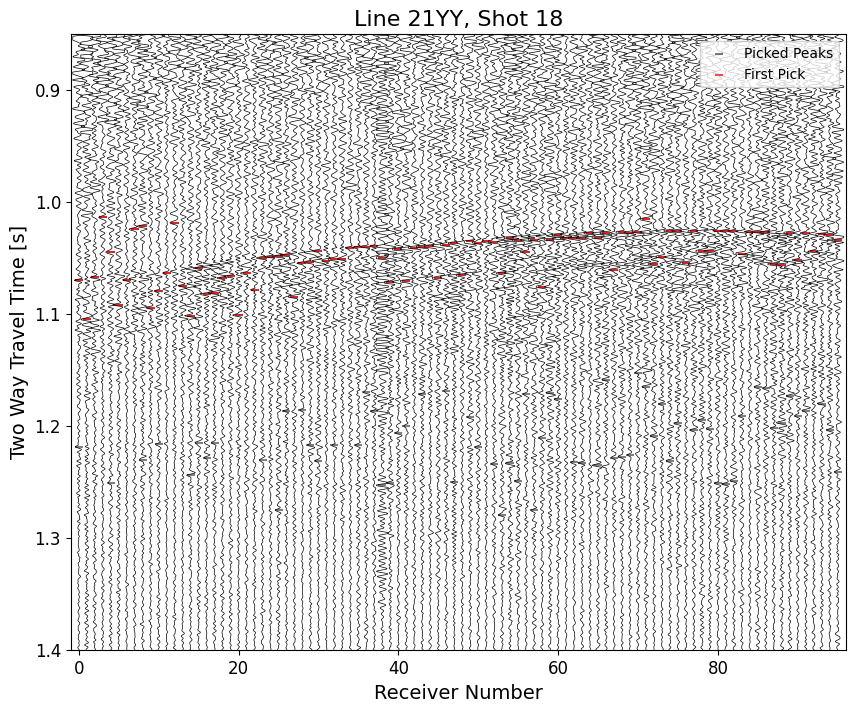

In [73]:
# Plot wiggle plots
#for fldr_number in  np.arange(1,num_shots +1):
for fldr_number in  np.arange(18,19):
    # Load data
    data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)
    geometry = pd.read_csv(geometry_path)
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
    assert len(subset_geometry['XSHOT']) == len(data_clipped[0]), "Incorrect length of shot data vs geometry file"

    # Calculate offset angles
    z = 2250 # Assume constant depth
    dist = np.array([np.sqrt((subset_geometry['XSHOT'][i]-subset_geometry['XREC'][i])**2 + (subset_geometry['YSHOT'][i]-subset_geometry['YREC'][i])**2 ) for i in range(len(subset_geometry['XSHOT']))])
    offset_angle = np.rad2deg(np.arctan2(dist, z))

    # Pick, plot and save peaks for each of the 96 traces recorded for each SHOT
    # For trace in the 96 traces, get the amplitude of the first reflection

    fig, ax = plt.subplots(figsize=(10, 8))
    st_time = 1.0
    et_time = 1.3

    # slice indices
    i1 = np.searchsorted(time, st_time)
    i2 = np.searchsorted(time, et_time)

    data_win = data_clipped[i1:i2, :]
    time_win = time[i1:i2]

    extent = [0, n_traces, time_win[-1], time_win[0]]

    traces = data_clipped
    for trace_no, trace in enumerate(traces.T):
        trace = trace * 3
        trace = np.clip(trace, -0.75, 0.75)
        x = trace_no * np.ones_like(trace) + trace
        ax.plot(x, time, color='k', linewidth=0.5,zorder=5)

    ax.set_xlim(-1, n_traces)       # traces 0..N
    ax.set_ylim(et_time + 0.1, st_time - 0.15)  # flip time axis (deeper at bottom)

    peak_indices_per_trace = [] # Save all peaks
    peak_props_per_trace = [] # Save all peak properties
    first_peak_time = np.full(data_clipped.shape[1], np.nan) # Save first peak
    first_peak_amp = np.full(data_clipped.shape[1], np.nan)   # Save first peak amplitude

    for trace_idx in range(data_clipped.shape[1]):
        trace = data_win[:, trace_idx]
        trace = -trace

        # Find peaks — add parameters as needed (height, distance, prominence…)
        peaks, props = find_peaks(trace, prominence=0.2, distance=500, height=0.1)

        if len(peaks) > 0:
            first_idx = peaks[0]          # earliest (shallowest) peak
            first_peak_amp[trace_idx] = -trace[first_idx] # Looking at minima still
            first_peak_time[trace_idx] = time_win[first_idx]

        peak_indices_per_trace.append(peaks)
        peak_props_per_trace.append(props)

    #print(first_peak_time)
    #print(first_peak_amp)

    peak_times = [time[peaks] for peaks in peak_indices_per_trace]
    peak_amps = [-data_clipped[peaks, tr] for tr, peaks in enumerate(peak_indices_per_trace)]

    for tr, peaks in enumerate(peak_indices_per_trace):
        if tr == 0:
            ax.scatter([tr]*len(peaks), time_win[peaks],color='black',marker='_',zorder=2,alpha=0.5,label='Picked Peaks')
        else:
            ax.scatter([tr]*len(peaks), time_win[peaks],color='black',marker='_',zorder=2,alpha=0.5)

    
    ax.scatter(np.arange(data_clipped.shape[1]),first_peak_time, color='red',marker="_",zorder=3,alpha=0.7, label='First Pick')
    #print(first_peak_amp)
    ax.set_xlabel("Receiver Number",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.set_title(f"Line {line}, Shot {fldr_number}",fontsize=16)
    ax.tick_params(labelsize=12)
    ax.legend(loc='upper right')


        

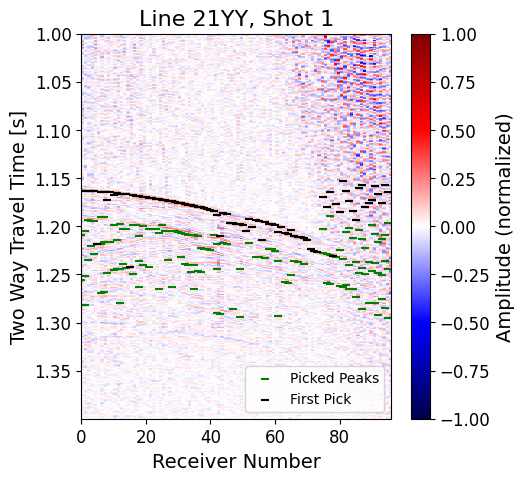

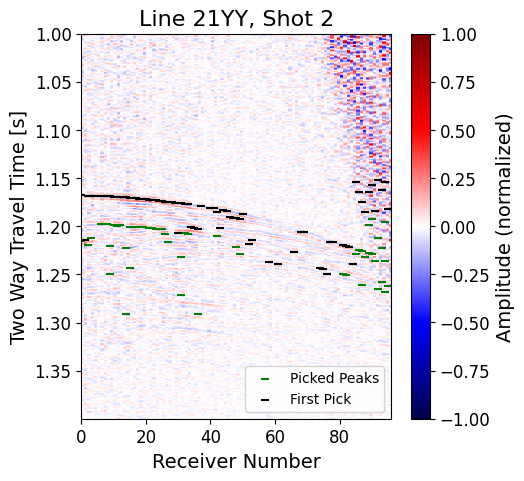

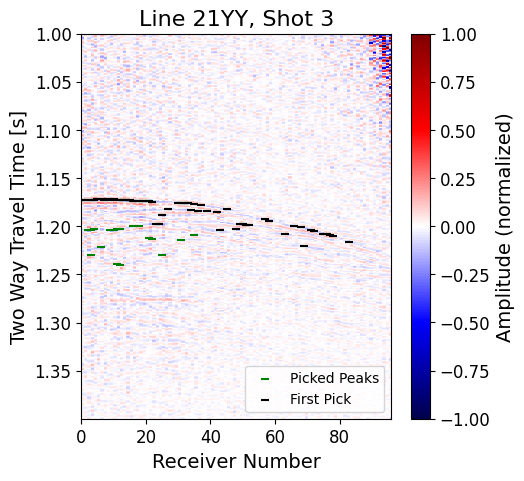

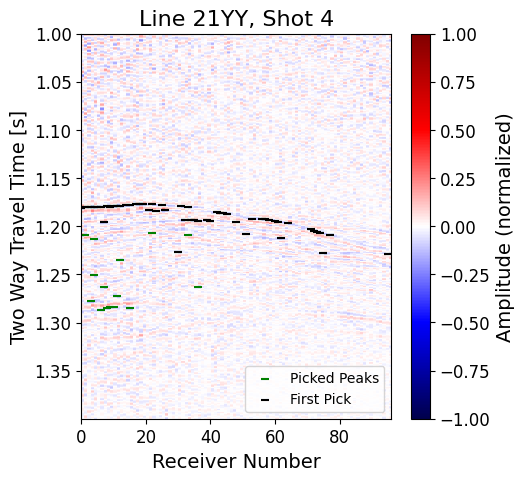

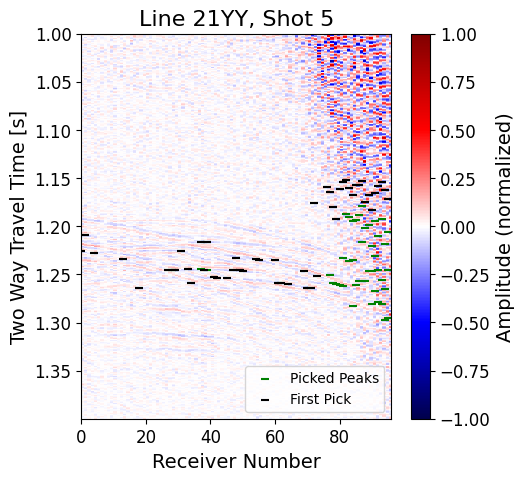

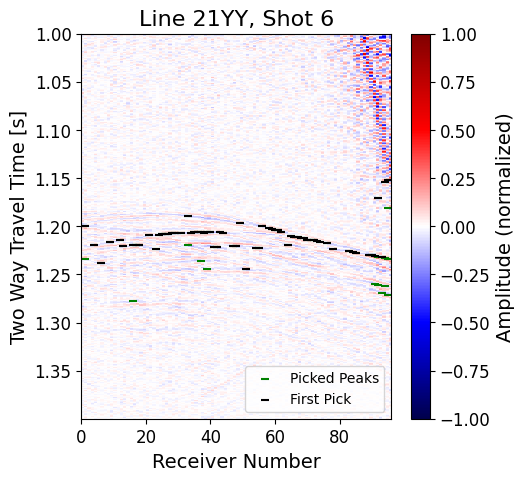

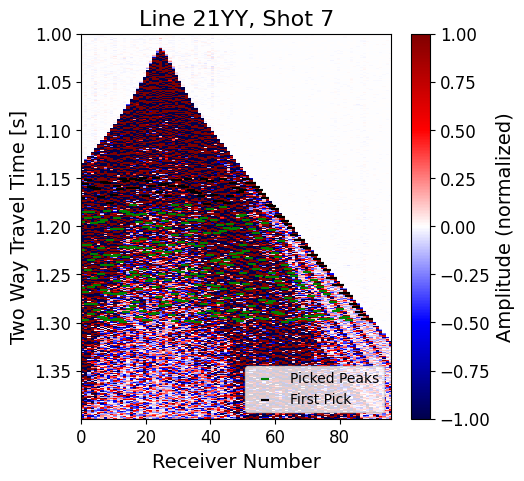

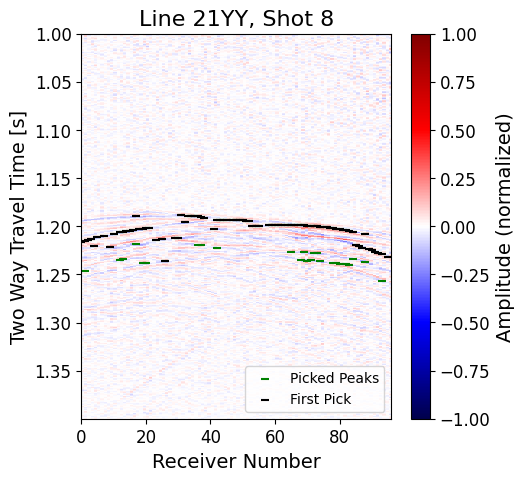

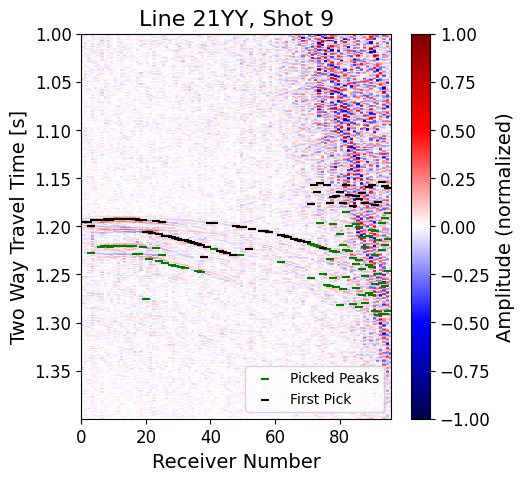

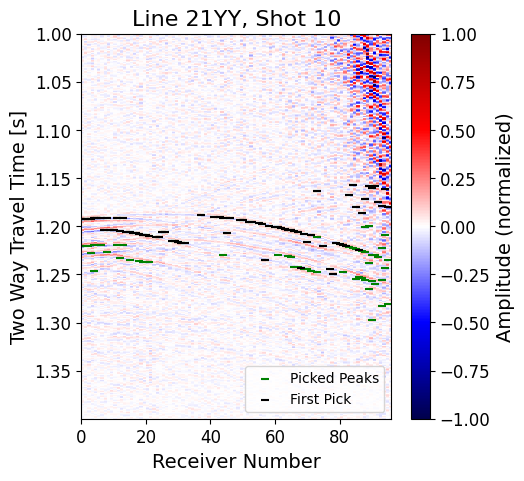

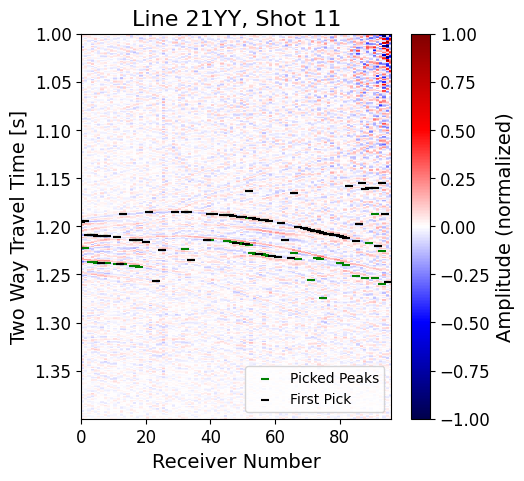

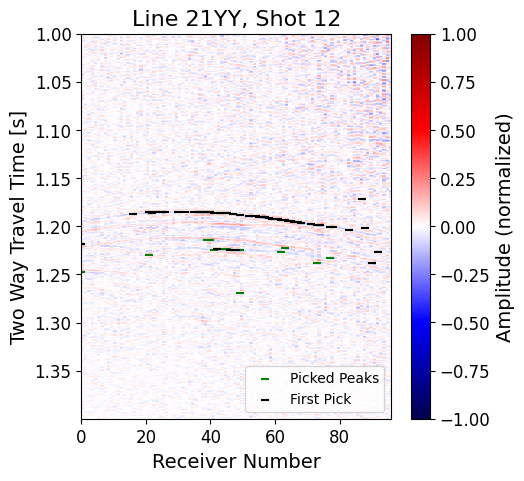

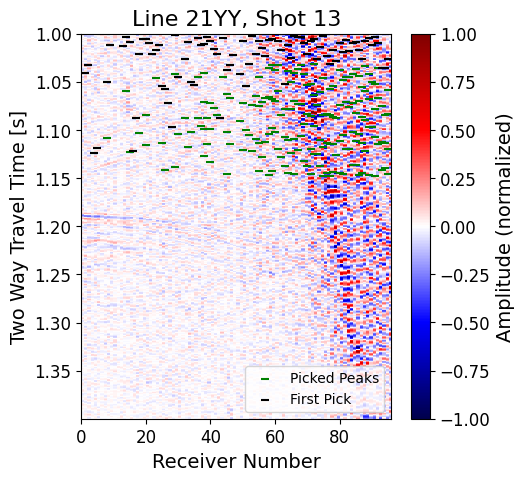

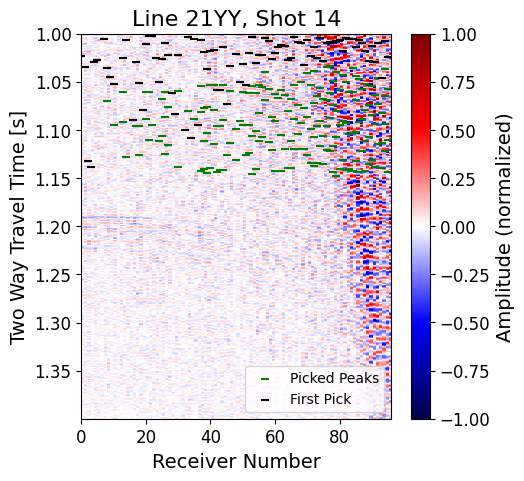

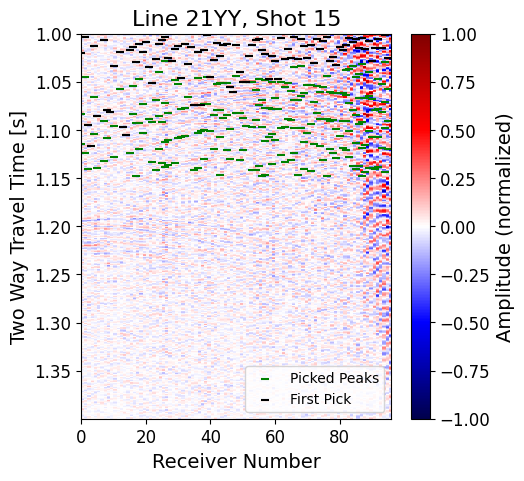

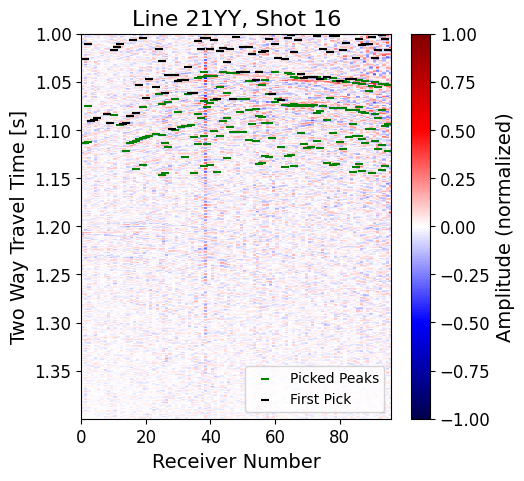

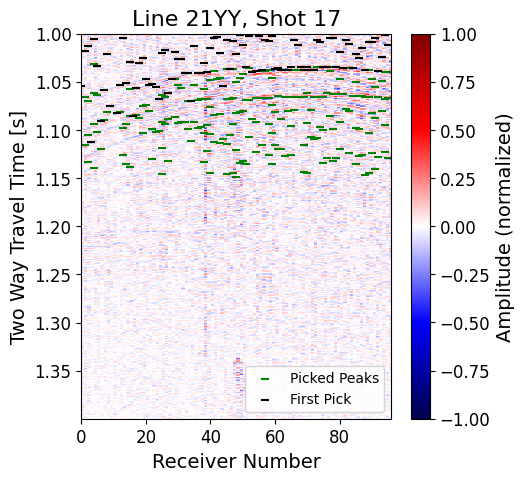

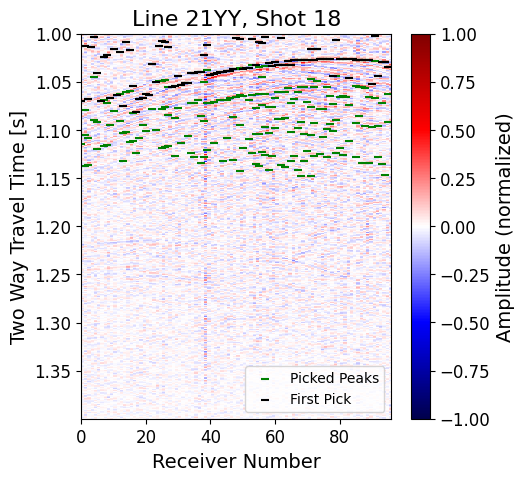

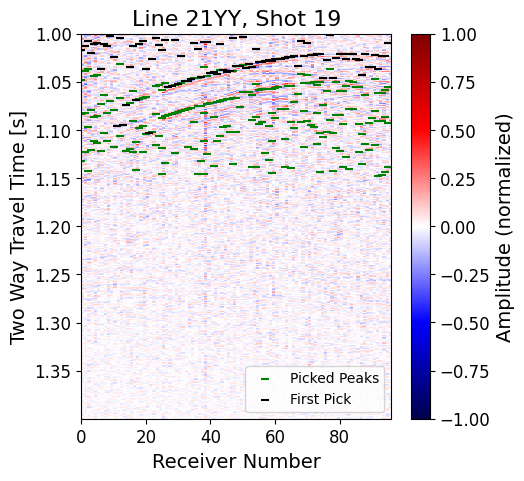

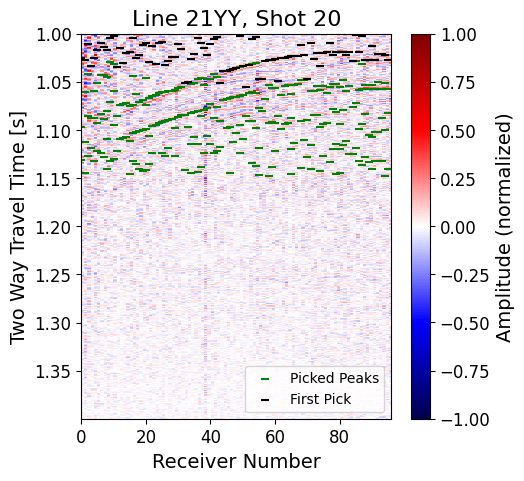

In [75]:
# Plot example amplitude plots

offset_angle_all = []
peak_amp_all = []
ran_fldr_numbers = []

for fldr_number in  np.arange(1,num_shots +1):
    # Load data
    data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)
    geometry = pd.read_csv(geometry_path)
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
    assert len(subset_geometry['XSHOT']) == len(data_clipped[0]), "Incorrect length of shot data vs geometry file"

    # Calculate offset angles
    z = 2250 # Assume constant depth
    dist = np.array([np.sqrt((subset_geometry['XSHOT'][i]-subset_geometry['XREC'][i])**2 + (subset_geometry['YSHOT'][i]-subset_geometry['YREC'][i])**2 ) for i in range(len(subset_geometry['XSHOT']))])
    offset_angle = np.rad2deg(np.arctan2(dist, z))

    # Pick, plot and save peaks for each of the 96 traces recorded for each SHOT
    # For trace in the 96 traces, get the amplitude of the first reflection

    fig, ax = plt.subplots(figsize=(5, 5))
    if fldr_number < 13:
        st_time = 1.15
        et_time = 1.3
    else:
        st_time = 1.0
        et_time = 1.15

    # slice indices
    i1 = np.searchsorted(time, st_time)
    i2 = np.searchsorted(time, et_time)

    data_win = data_clipped[i1:i2, :]
    time_win = time[i1:i2]

    extent = [0, n_traces, time_win[-1], time_win[0]]

    st_p_time = 1
    et_p_time = 1.4
    ip1 = np.searchsorted(time, st_p_time)
    ip2 = np.searchsorted(time, et_p_time)
    data_p_win = data_clipped[ip1:ip2, :]
    time_p_win = time[ip1:ip2]

    extent = [0, n_traces, time_p_win[-1], time_p_win[0]]


    im = ax.imshow(
        data_p_win,
        cmap='seismic',
        interpolation='none',
        aspect='auto',
        extent=extent,
        vmin=-1, vmax=1
    )


    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Amplitude (normalized)', fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    peak_indices_per_trace = [] # Save all peaks
    peak_props_per_trace = [] # Save all peak properties
    first_peak_time = np.full(data_clipped.shape[1], np.nan) # Save first peak
    first_peak_amp = np.full(data_clipped.shape[1], np.nan)   # Save first peak amplitude

    first_peak_1_shot = []
    offset_angle_1_shot = []
    for trace_idx in range(data_clipped.shape[1]):
        trace = data_win[:, trace_idx]
        trace = -trace

        # Find peaks — add parameters as needed (height, distance, prominence…)
        #peaks, props = find_peaks(trace, prominence=0.1, distance=10, height=0.1)
        peaks, props = find_peaks(trace, prominence=0.15, distance=100, height=0.13)

        if len(peaks) > 0:
            first_idx = peaks[0]          # earliest (shallowest) peak
            first_peak_amp[trace_idx] = -trace[first_idx] # Looking at minima still
            first_peak_time[trace_idx] = time_win[first_idx]

        peak_indices_per_trace.append(peaks)
        peak_props_per_trace.append(props)

        first_peak_1_shot.append(first_peak_amp)
        offset_angle_1_shot.append(offset_angle)

    #print(first_peak_time)
    #print(first_peak_amp)

    peak_times = [time[peaks] for peaks in peak_indices_per_trace]
    peak_amps = [-data_clipped[peaks, tr] for tr, peaks in enumerate(peak_indices_per_trace)]

    for tr, peaks in enumerate(peak_indices_per_trace):
        if tr == 0:
            ax.scatter([tr]*len(peaks), time_win[peaks],color='green',marker='_',zorder=2,label='Picked Peaks')
        else:
            ax.scatter([tr]*len(peaks), time_win[peaks],color='green',marker='_',zorder=2)
   
    ax.scatter(np.arange(data_clipped.shape[1]),first_peak_time, color='black',marker="_",zorder=3, label='First Pick')
    #print(first_peak_amp)
    ax.set_xlabel("Receiver Number",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.set_title(f"Line {line}, Shot {fldr_number}",fontsize=16)
    ax.tick_params(labelsize=12)
    ax.legend(loc='lower right')

    offset_angle_all.append(offset_angle_1_shot)
    peak_amp_all.append(first_peak_1_shot)
    ran_fldr_numbers.append(fldr_number)
    

        

Water: R0=-0.395, G=0.527
Basement: R0=0.646, G=-0.804
Stiff: R0=-0.011, G=-0.094
Dilatant: R0=-0.059, G=0.337
Lithified: R0=0.446, G=-0.954
5


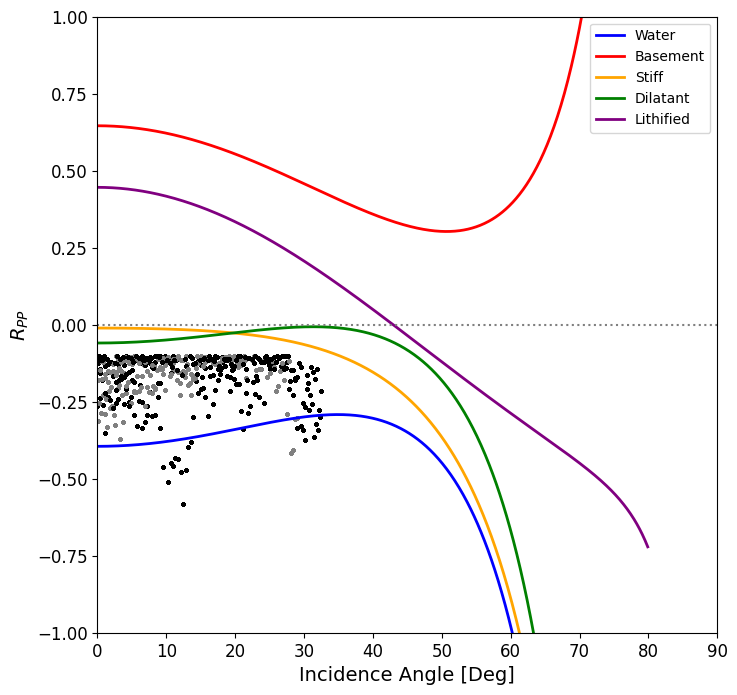

In [12]:
# Plot theoretical curves and data points
angles = np.arange(0, 80, 0.1)
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['blue', 'red', 'orange','green', 'purple']
for color, (name, props) in zip(colors, materials.items()):
    #R = Aki_Richards_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    R, R0, G = Shuey_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    ax.plot(angles, R, color=color, label=name, linewidth=2)
    ax.legend()
    print(f"{name}: R0={R0:.3f}, G={G:.3f}")
ax.set_ylim(-1,1)
ax.set_xlim(0,90)
ax.axhline(0, color='gray', linestyle=':')
ax.set_ylabel(r'$R_{PP}$',fontsize=14)
ax.set_xlabel('Incidence Angle [Deg]',fontsize=14)
ax.tick_params(labelsize=12)


clr_scatter = ['black','gray','black','gray','black','gray']
print(len(offset_angle_all))
for color, offset_angle, first_peak_amp in zip(clr_scatter, offset_angle_all, peak_amp_all):
    ax.scatter(offset_angle, first_peak_amp, color=color,marker='.',s=10)


Water: R0=-0.395, G=0.527
Basement: R0=0.646, G=-0.804
Stiff: R0=-0.011, G=-0.094
Dilatant: R0=-0.059, G=0.337
Lithified: R0=0.446, G=-0.954
5


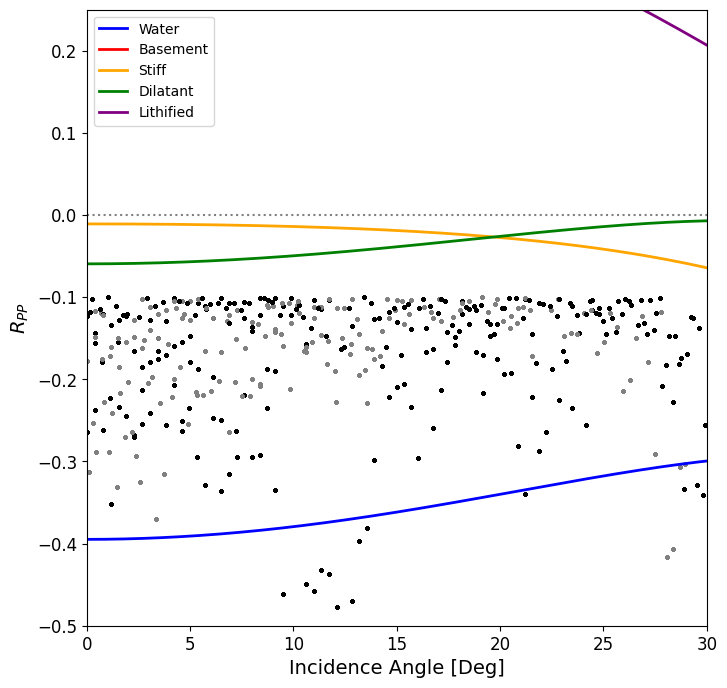

In [13]:
# Plot theoretical curves and data points
angles = np.arange(0, 80, 0.1)
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['blue', 'red', 'orange','green', 'purple']
for color, (name, props) in zip(colors, materials.items()):
    #R = Aki_Richards_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    R, R0, G = Shuey_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    ax.plot(angles, R, color=color, label=name, linewidth=2)
    ax.legend()
    print(f"{name}: R0={R0:.3f}, G={G:.3f}")
ax.set_ylim(-0.5,0.25)
ax.set_xlim(0,30)
ax.axhline(0, color='gray', linestyle=':')
ax.set_ylabel(r'$R_{PP}$',fontsize=14)
ax.set_xlabel('Incidence Angle [Deg]',fontsize=14)
ax.tick_params(labelsize=12)


clr_scatter = ['black','gray','black','gray','black','gray']
print(len(offset_angle_all))
for color, offset_angle, first_peak_amp in zip(clr_scatter, offset_angle_all, peak_amp_all):
    ax.scatter(offset_angle, first_peak_amp, color=color,marker='.',s=10)


50 50
-0.3990860900287712 -0.2747051200461904
48 48
1.824240329587073 -0.24831950070757167
41 41
-1.3685425148788244 -0.2015397636917723
37 37
-0.7030408242450703 -0.16325510213265254
20 20
0.09781622976449052 -0.15642245199336247
33 33
-0.12896356248050056 -0.16294614874047345
50 50
-184.61912525394783 -16.935709532208957
40 40
0.3653123176915737 -0.18530820186731106
48 48
2.1936047061192845 -0.3246880987807236
42 42
0.04826366842484222 -0.17353025980444714
44 44
-0.2367768986163152 -0.14813561008038148
43 43
-0.28091092247772437 -0.16145937549046127
40 40
-0.3768458460463531 -0.4066971578093389
40 40
-3.950427154578676 0.07298224032085682
40 40
-2.5431235599107445 -0.06610363876670394
40 40
-0.4225358100196093 -0.18925524980322403
40 40
0.2926078425963131 -0.24272707446548095
40 40
-0.44404526895419183 -0.2925509454333873
40 40
-0.5296986364660401 -0.23110300637148629
40 40
0.037923497717486106 -0.24654748150210504


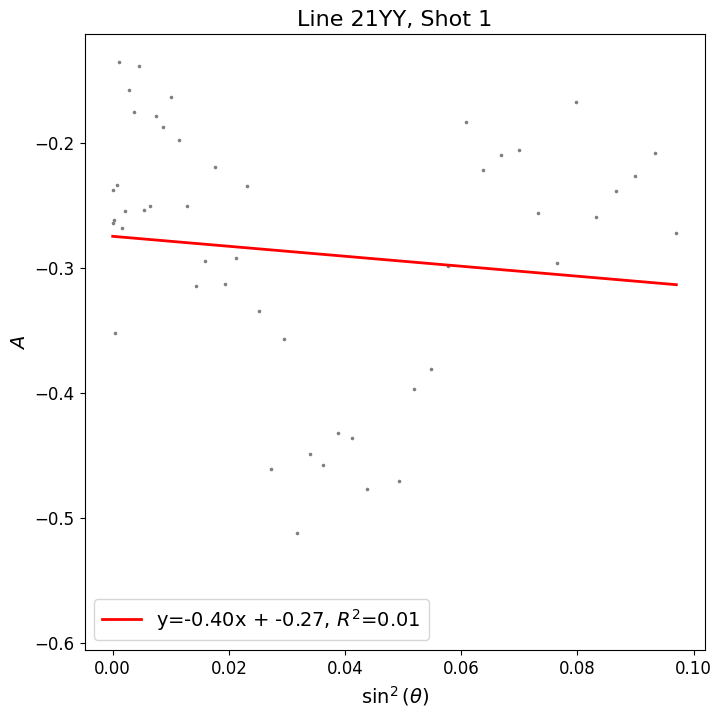

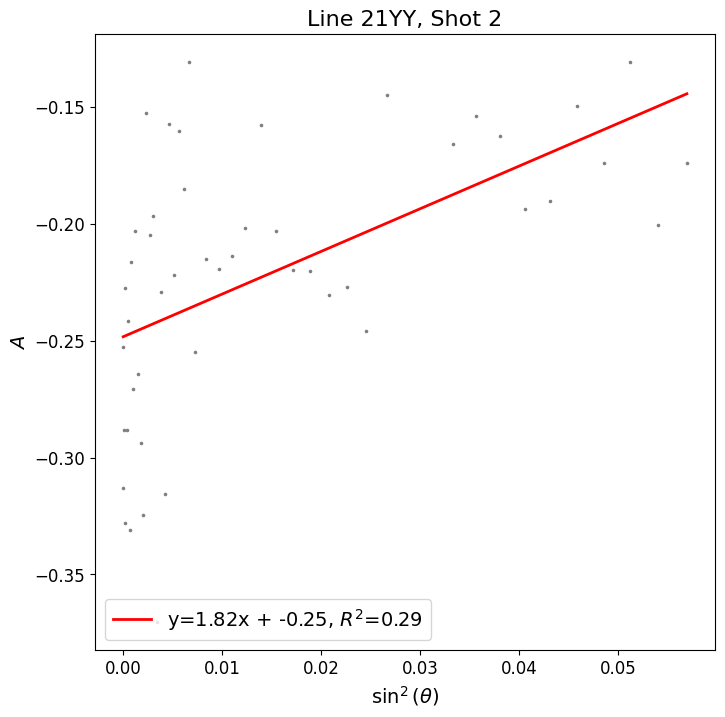

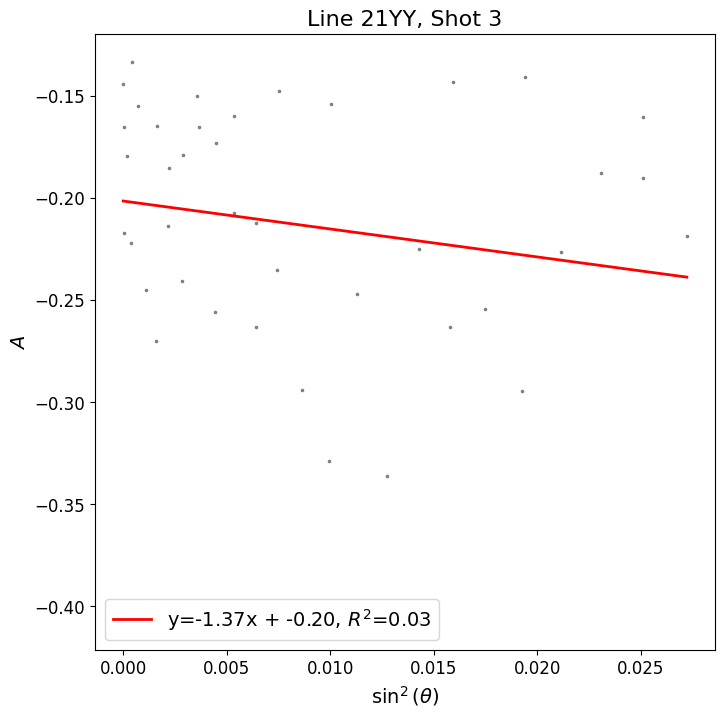

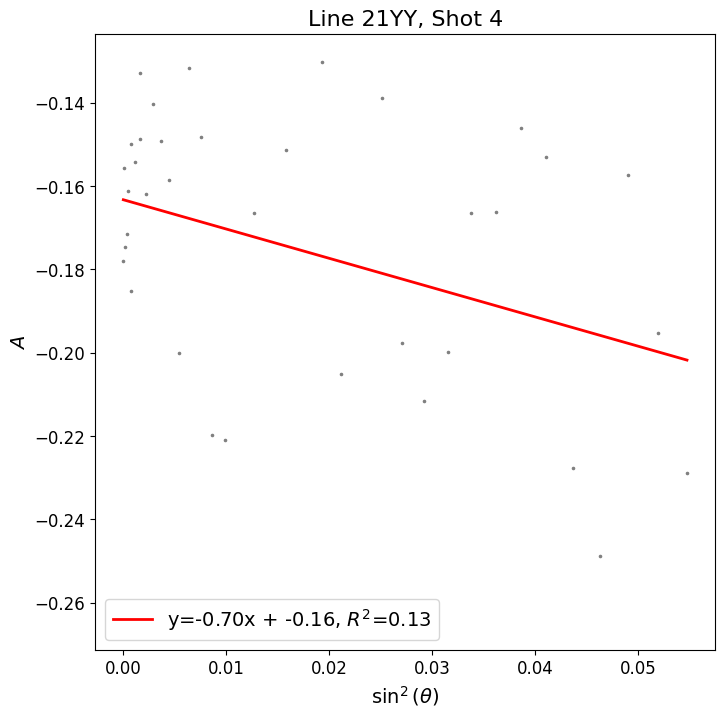

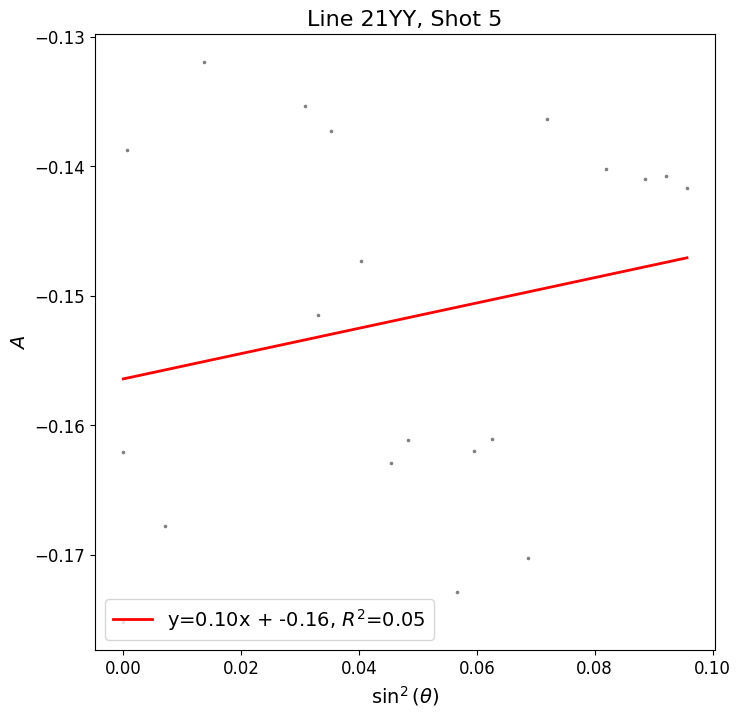

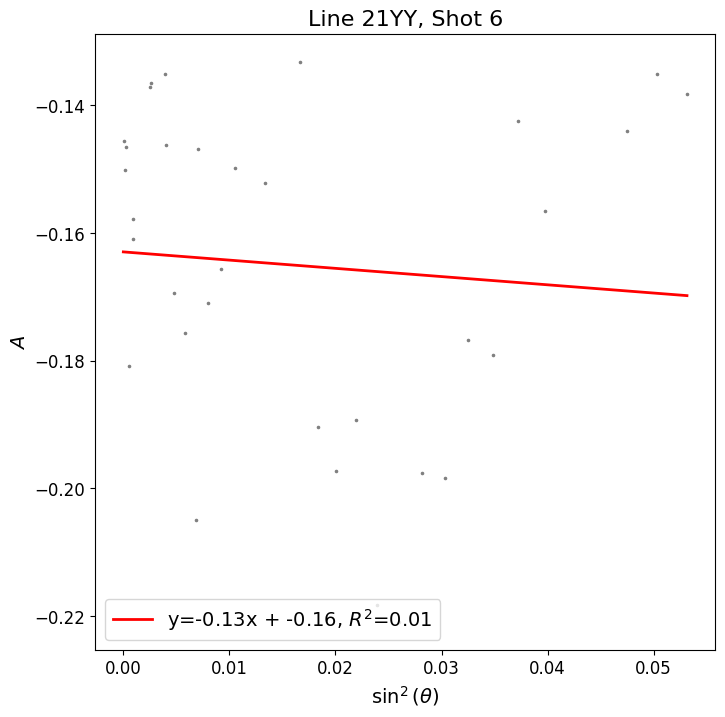

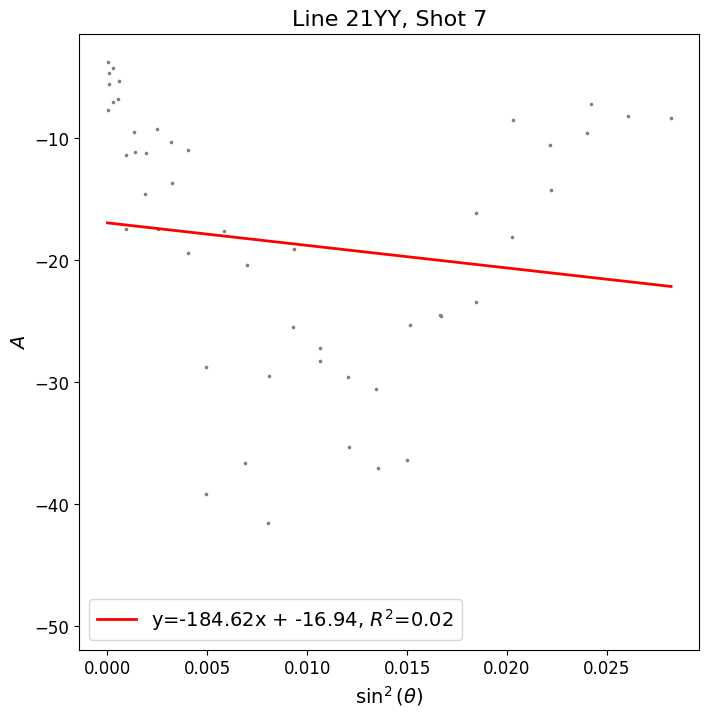

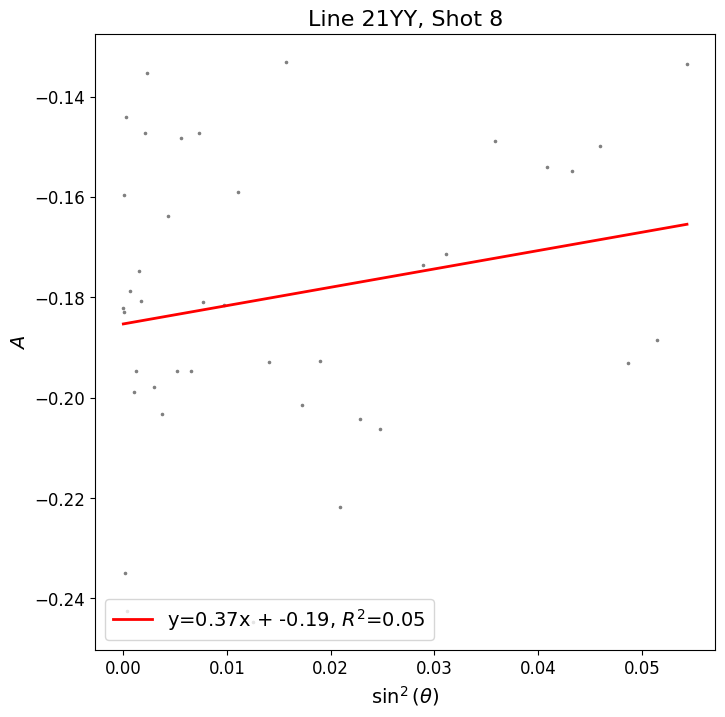

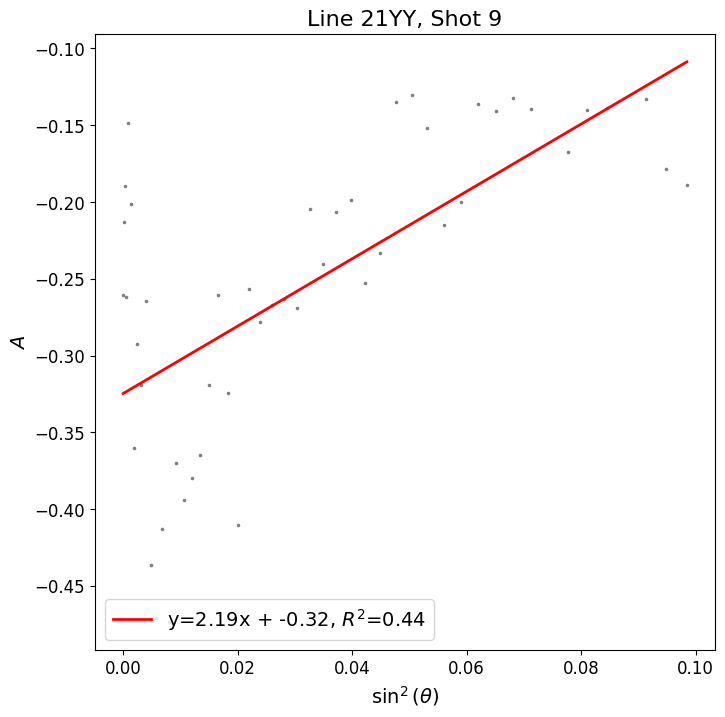

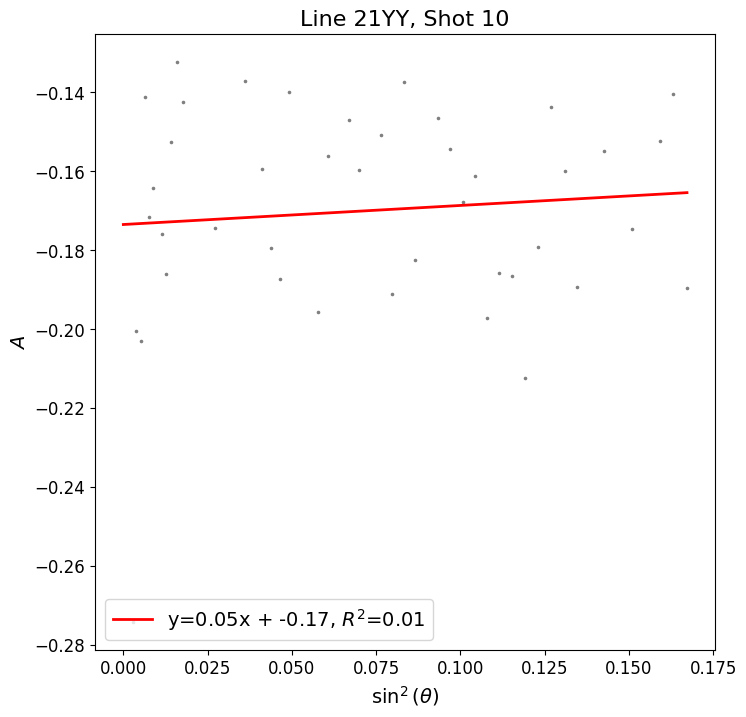

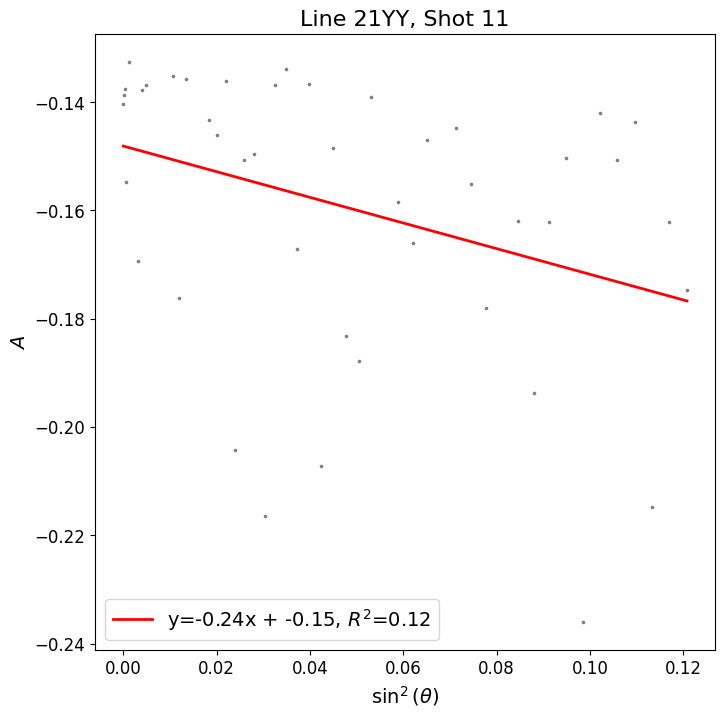

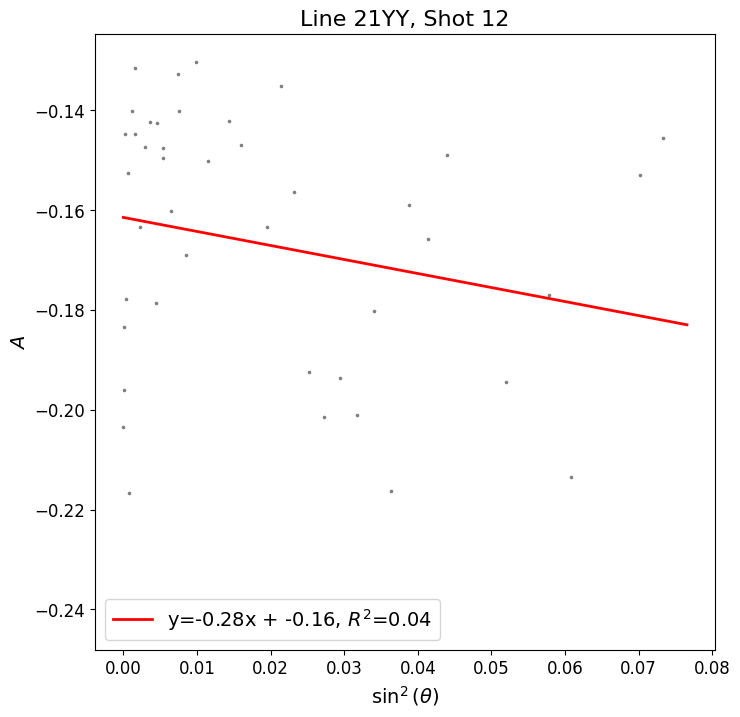

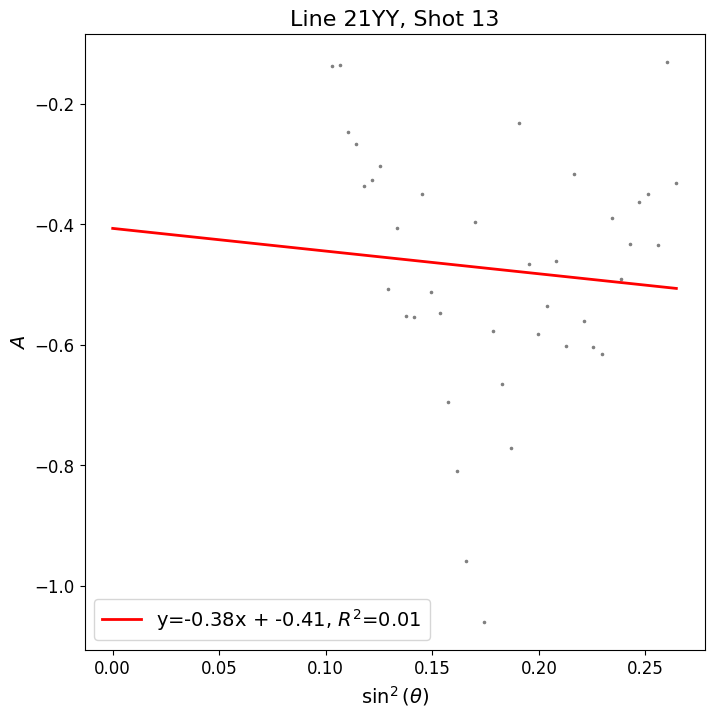

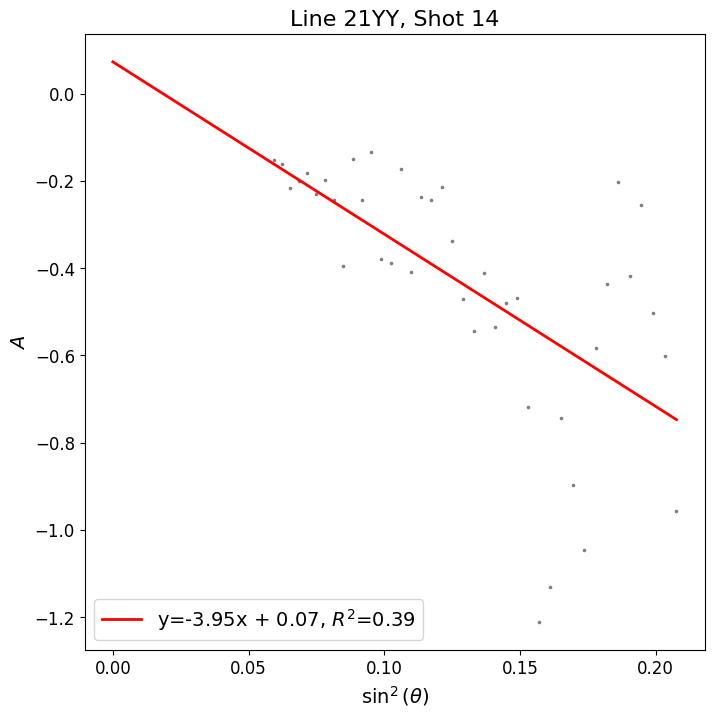

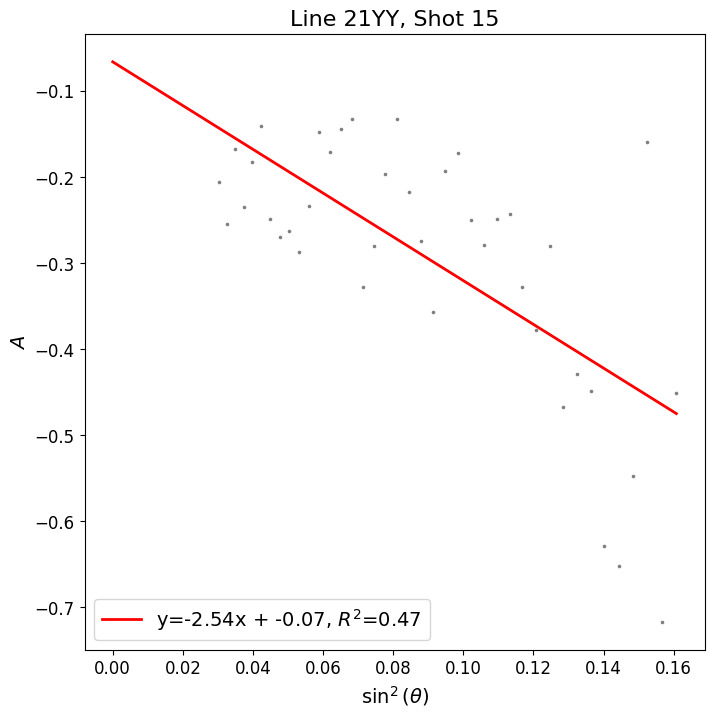

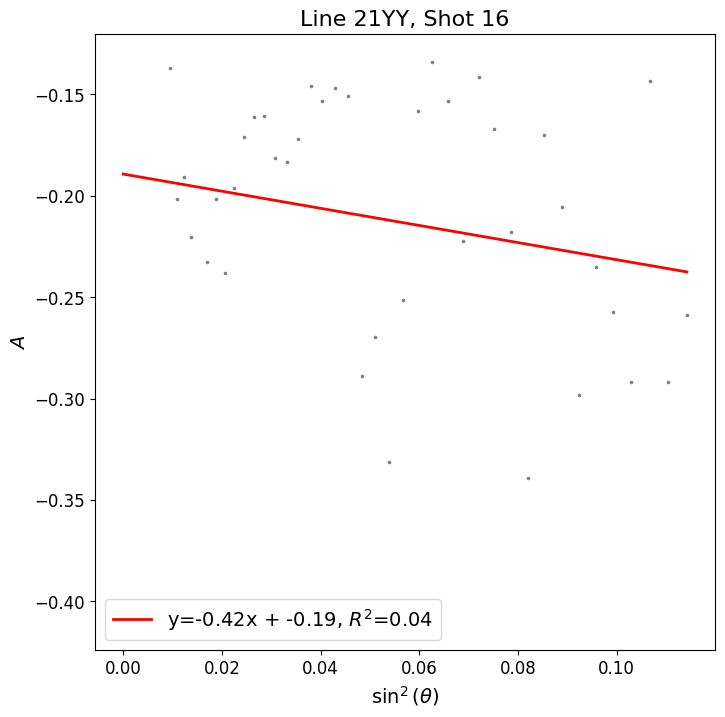

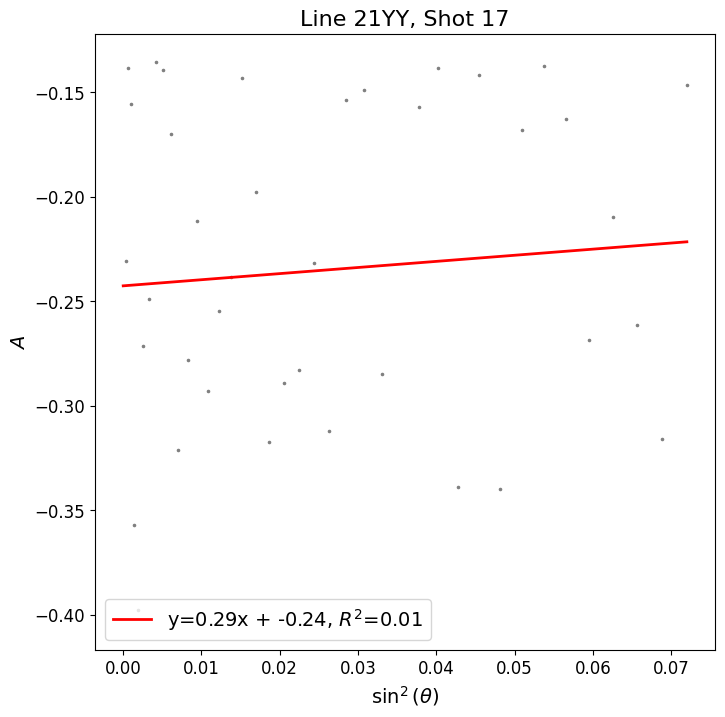

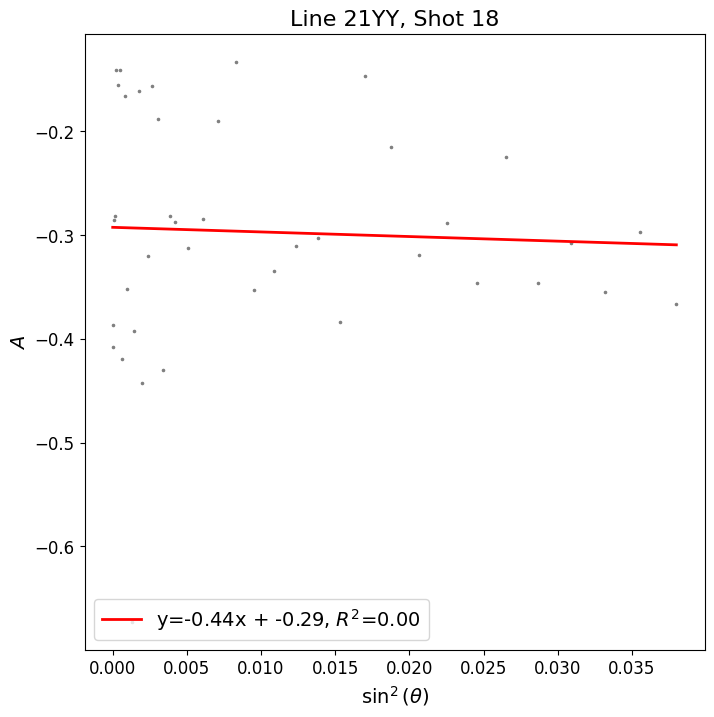

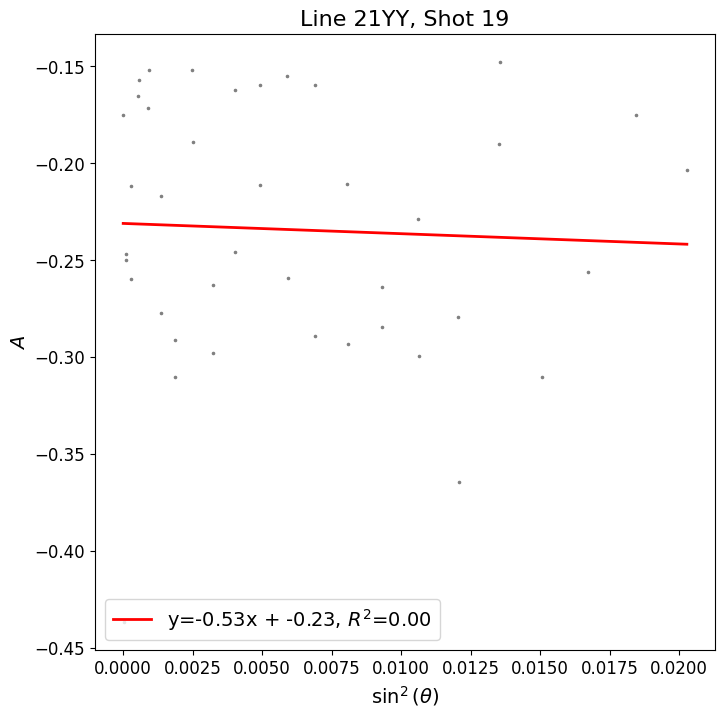

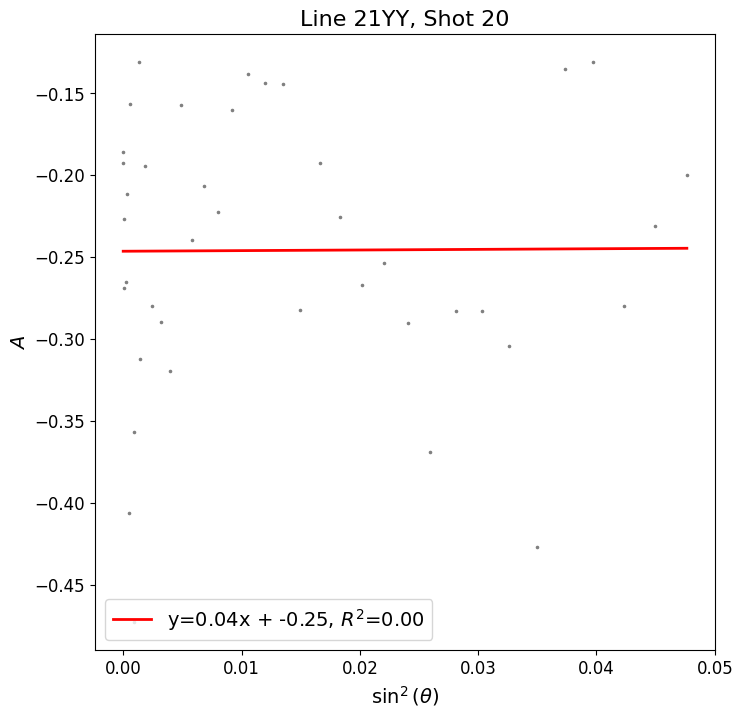

In [76]:
# Create linear regression fit
plot = True

regressions = {'slope':[], 'intercept':[]}
for ran_fldr_number, offset_angle, first_peak_amp in zip(ran_fldr_numbers, offset_angle_all, peak_amp_all):

    if ran_fldr_number < 10:
        trusted_start = 0
        trusted_end = 50
    elif ran_fldr_number < 13:
        trusted_start = 20
        trusted_end = 80
    else:
        trusted_start = 50
        trusted_end = 90
    off_clip = offset_angle[0][trusted_start:trusted_end]
    amp_clip = first_peak_amp[0][trusted_start:trusted_end]
    mask = np.isfinite(off_clip) & np.isfinite(amp_clip)
    sin_2_angle = np.sin(np.deg2rad(off_clip))**2
    print(len(sin_2_angle[mask]), len(amp_clip[mask]))

    #slope, intercept = np.polyfit(sin_2_angle[mask], first_peak_amp[0][mask], 1) #Offset angle is nested list but identical for each
    res = scipy.stats.linregress(sin_2_angle[mask], amp_clip[mask])

    slope = res.slope
    intercept = res.intercept
    r2 = res.rvalue**2
    regressions['slope'].append(slope)
    regressions['intercept'].append(intercept)

    print(slope, intercept)
    if plot:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.scatter(sin_2_angle, amp_clip, color='gray',marker='.',s=10)
        # Plot lin regression
        x_vals = np.linspace(0, np.max(sin_2_angle), 100)
        y_vals = intercept + slope * x_vals
        ax.plot(x_vals, y_vals, color='red', linewidth=2, label=f'y={slope:.2f}x + {intercept:.2f}, $R^2$={r2:.2f}')
        ax.set_xlabel(r'$\sin^2(\theta)$', fontsize=14)
        ax.set_ylabel(r'$A$', fontsize=14)
        ax.legend(fontsize=14, loc='lower left')
        ax.set_title(f'Line {line}, Shot {ran_fldr_number}', fontsize=16)
        ax.tick_params(labelsize=12)


        
        

/tmp/ipykernel_1934/1128546846.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", N)


(-4.0, 4.0)

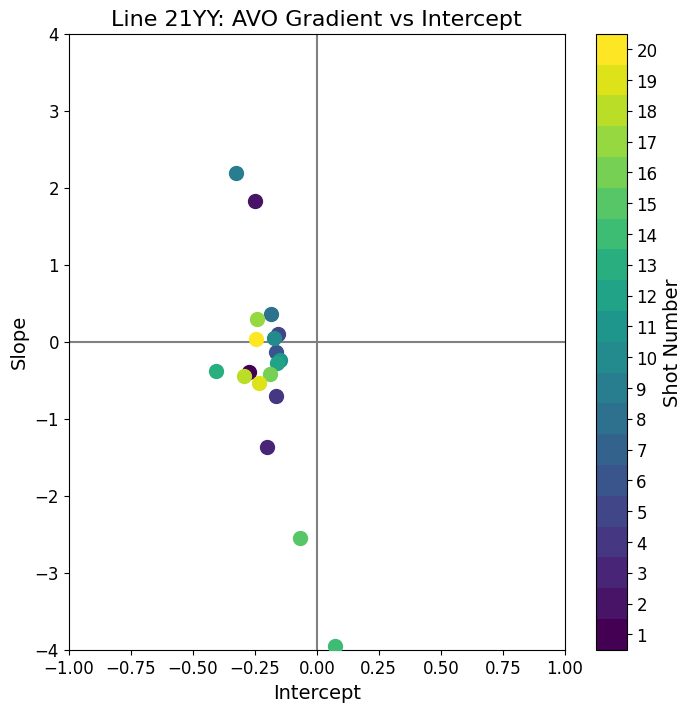

In [93]:
# Scatter plot

vals = np.asarray(ran_fldr_numbers)
N = 20 # Bins

# Normalize for colormap (maps min→0, max→1)
norm = plt.Normalize(vals.min(), vals.max())
cmap = plt.cm.get_cmap("viridis", N)

fig, ax = plt.subplots(figsize=(8, 8))

ax.axhline(0, color='gray', linestyle='-')
ax.axvline(0, color='gray', linestyle='-')
# Scatter slope, intercept, color is shot color viridis
for ran_fldr_number, slope, intercept in zip(ran_fldr_numbers, regressions['slope'], regressions['intercept']):
    color = cmap(norm(ran_fldr_number))
    ax.scatter(intercept, slope, color=color, marker='o', s=100,zorder=3)
# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Shot Number', fontsize=14)
cbar.ax.tick_params(labelsize=12)
bin_edges = np.linspace(vals.min(), vals.max(), N + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
cbar.set_ticks(bin_centers)
cbar.set_ticklabels(np.arange(1, N + 1))


ax.set_ylabel('Slope', fontsize=14)
ax.set_xlabel('Intercept', fontsize=14)
ax.set_title(f'Line {line}: AVO Gradient vs Intercept', fontsize=16)
ax.tick_params(labelsize=12)

ax.set_xlim(-1, 1)
ax.set_ylim(-4, 4)
